# Otto Cycle Simulator

Enter Compression Ratio (r = V1/V2) [typical 8-12]: 8
Enter T1 (K) [intake temperature, e.g. 300]: 312
Enter Heat added Q23 (kJ) [per cycle, e.g. 800]: 1200

OTTO CYCLE SIMULATOR
Compression Ratio (r)     = 8.0
T1 = 312.0 K    T2 = 716.8 K
T3 = 1916.8 K    T4 = 834.3 K
Heat Input (Q_in)         = 1200.0 kJ
Heat Rejected (Q_out)     = 522.3 kJ
Thermal Efficiency        = 56.47 %


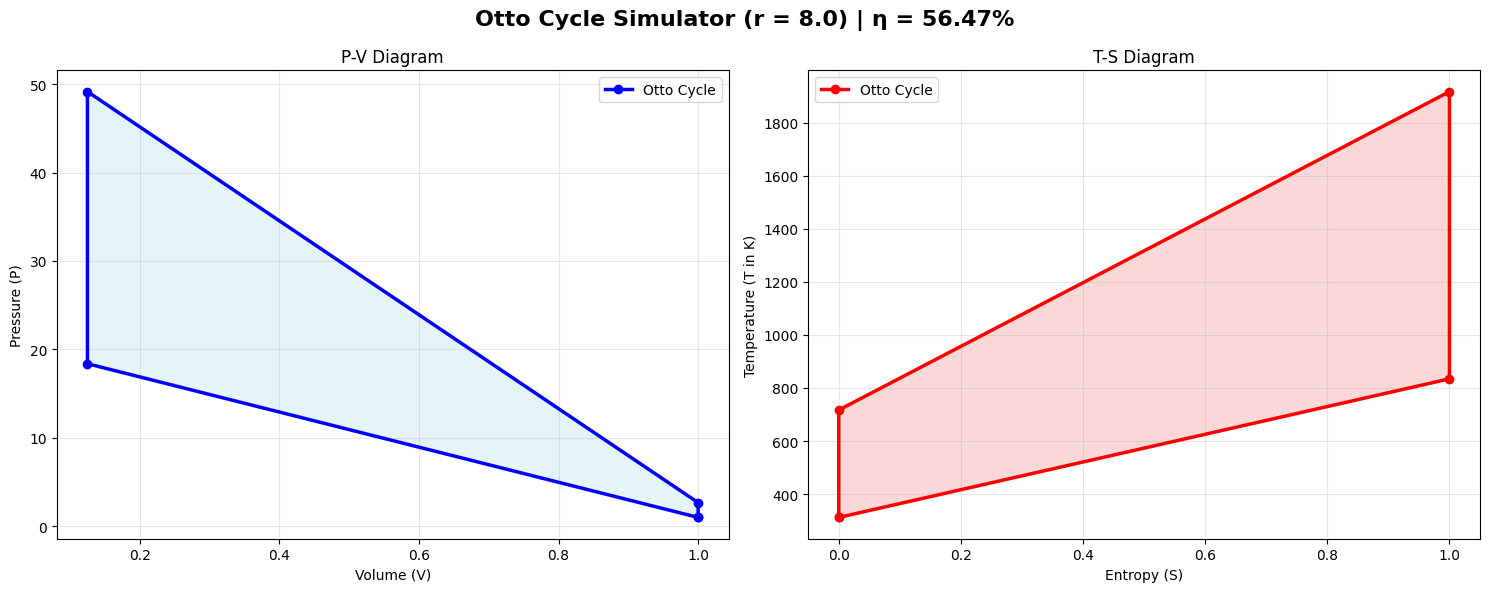

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== USER INPUTS ======================
r = float(input("Enter Compression Ratio (r = V1/V2) [typical 8-12]: "))   # e.g. 10
T1 = float(input("Enter T1 (K) [intake temperature, e.g. 300]: "))         # e.g. 300
Q_in = float(input("Enter Heat added Q23 (kJ) [per cycle, e.g. 800]: "))   # e.g. 800
gamma = 1.4   # For air (constant)

# ====================== CALCULATIONS ======================
# Process 1-2: Isentropic compression
T2 = T1 * (r ** (gamma - 1))
V1 = 1.0                    # Assume V1 = 1 m^3
V2 = V1 / r
P1 = 1.0                    # Assume P1 = 1 bar
P2 = P1 * (r ** gamma)

# Process 2-3: Constant volume heat addition
T3 = T2 + (Q_in / 1.0)      # Cv = 1 for simplicity (normalized)
V3 = V2
P3 = P2 * (T3 / T2)

# Process 3-4: Isentropic expansion
T4 = T3 * ((1/r) ** (gamma - 1))
V4 = V1
P4 = P3 * ((1/r) ** gamma)

# Process 4-1: Constant volume heat rejection
Q_out = T4 - T1             # Normalized

# Efficiency
eta = 1 - (1 / (r ** (gamma - 1)))
eta_percent = eta * 100

print("\n" + "="*70)
print("OTTO CYCLE SIMULATOR")
print("="*70)
print(f"Compression Ratio (r)     = {r}")
print(f"T1 = {T1:.1f} K    T2 = {T2:.1f} K")
print(f"T3 = {T3:.1f} K    T4 = {T4:.1f} K")
print(f"Heat Input (Q_in)         = {Q_in} kJ")
print(f"Heat Rejected (Q_out)     = {Q_out:.1f} kJ")
print(f"Thermal Efficiency        = {eta_percent:.2f} %")
print("="*70)

# ====================== PLOTS ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Otto Cycle Simulator (r = {r}) | η = {eta_percent:.2f}%', fontsize=16, fontweight='bold')

# PV Diagram
V = np.array([V1, V2, V2, V4, V1])
P = np.array([P1, P2, P3, P4, P1])
ax1.plot(V, P, 'b-o', linewidth=2.5, label='Otto Cycle')
ax1.fill(V, P, 'lightblue', alpha=0.3)
ax1.set_xlabel('Volume (V)')
ax1.set_ylabel('Pressure (P)')
ax1.set_title('P-V Diagram')
ax1.grid(True, alpha=0.3)
ax1.legend()

# TS Diagram
S = np.array([0, 0, 1, 1, 0])          # Normalized entropy change
T = np.array([T1, T2, T3, T4, T1])
ax2.plot(S, T, 'r-o', linewidth=2.5, label='Otto Cycle')
ax2.fill(S, T, 'lightcoral', alpha=0.3)
ax2.set_xlabel('Entropy (S)')
ax2.set_ylabel('Temperature (T in K)')
ax2.set_title('T-S Diagram')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()